In [45]:
import glob
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
#collect files
files = glob.glob(os.path.join('ticket_data', 'tickets_*.csv'))
print(f"{len(files)} files")

26 files


In [3]:
#combine files
tickets = []

for file in files:
    df = pd.read_csv(file) 
    tickets.append(df)      

all_tickets = pd.concat(tickets, ignore_index=True)

print(f"{len(all_tickets)} rows")
display(all_tickets.head()) 

5017 rows


,id,eventId,section,sectionId,sectionMapName,sectionType,row,seat,seatFromInternal,hasSeatDetails,...,bestDealTagMessage.hasValue,bestDealTagMessage.featureTrackingKey,bestViewTagMessage.message,bestViewTagMessage.disclaimer,bestViewTagMessage.hasValue,bestViewTagMessage.featureTrackingKey,adAttributes.bidId,hiddenGemMessage.message,hiddenGemMessage.hasValue,hiddenGemMessage.featureTrackingKey
0,13390293526,153020449,307,122900,307,2,10,_,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13388100640,153020449,349,122942,349,2,17,13_13,13.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13387500802,153020449,331,122924,331,2,24,28_28,28.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13387888486,153020449,336,122929,336,2,25,26_26,26.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13387139253,153020449,319,122912,319,2,14,9_9,9.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#add 'scraped_time'
files = glob.glob(os.path.join('ticket_data', 'tickets_*.csv'))
tickets = []

for file in files:
    df = pd.read_csv(file)
    originalname = os.path.basename(file)
    time_str = originalname.replace('tickets_', '').replace('.csv', '')
    scraped_time = datetime.datetime.strptime(time_str, '%Y%m%d_%H%M')
    df['scraped_time'] = scraped_time
    tickets.append(df)

all_tickets = pd.concat(tickets, ignore_index=True)
print(f"{len(all_tickets)} rows with scraped time")
display(all_tickets[['scraped_time', 'id', 'section', 'rawPrice']].head())

5017 rows with scraped time


,scraped_time,id,section,rawPrice
0,2026-07-18 08:09:00,13390293526,307,1592430
1,2026-07-18 08:09:00,13388100640,349,1597064
2,2026-07-18 08:09:00,13387500802,331,1597064
3,2026-07-18 08:09:00,13387888486,336,1614609
4,2026-07-18 08:09:00,13387139253,319,1623382


In [5]:
#add 'price_usd'

exchange_rate = 162

all_tickets['price_usd'] = (all_tickets['rawPrice'] / exchange_rate).astype(int)
all_tickets['price'] = all_tickets['price_usd'].apply(lambda x: f"${x:,}")
display(all_tickets[['id', 'section', 'rawPrice', 'price','price_usd']].tail())

,id,section,rawPrice,price,price_usd
5012,12850878976,140,6209133,"$38,327",38327
5013,13365545787,5 S23,6823179,"$42,118",42118
5014,13039179808,129,7018114,"$43,321",43321
5015,13360117497,Spain Supporters Premium Tier,7803604,"$48,170",48170
5016,13369997536,113,11147815,"$68,813",68813


In [6]:
#total ids
all_tickets['id'].count()

np.int64(5017)

In [7]:
#total tickets
all_tickets['availableTickets'].sum()

np.int64(11875)

In [8]:
#total unique ids 
all_tickets['id'].nunique() 

1022

In [9]:
#total unique tickets
all_tickets.groupby('id')['availableTickets'].max().sum()

np.int64(2489)

In [10]:
#check event id
(all_tickets['eventId'] != 153020449).sum()


np.int64(0)

In [11]:
#confirm columns
for col in all_tickets.columns:
    print(col)

id
eventId
section
sectionId
sectionMapName
sectionType
row
seat
seatFromInternal
hasSeatDetails
hasSeatDetailsExpansion
availableTickets
formattedFees
showRecentlySold
showPartnershipLogo
availableQuantities
ticketClass
ticketClassName
maxQuantity
hasListingNotes
listingNotes
listingNoteBuckets
rowId
isUsersListing
isPreUploaded
rowContent
isSpeculativeRow
rawPrice
price
formattedTotalPrice
ticketTypeId
ticketTypeName
ticketTypeGroupId
listingTypeId
listingCurrencyCode
buyerCurrencyCode
faceValue
faceValueCurrencyCode
vfsUrl
formattedActiveSince
formattedDealScore
isSeatedTogether
showVfsInListing
hideSeatAndRowInfo
isUnmappedSection
aipHash
isMLBVerified
createdDateTime
showCheapestTag
showBestDealTag
showBestDealInSectionTag
showFanFavoriteTag
showBestViewTag
showTopChoiceTag
topChoiceBucket
isMostAffordable
winningMerchTags
suppressedMerchTags
isZoneTicketClass
isSponsored
isSponsoredSecondary
isMirrorListing
crossSellSource
isCheapestListing
isFavorite
aggregateFavorites
listingId

In [12]:
# col 'id' = col 'listingId' 
(all_tickets['id'] != all_tickets['listingId']).sum()

np.int64(0)

In [13]:
# col 'section' = col 'sectionMapName' 
(all_tickets['section'] != all_tickets['sectionMapName']).sum()

np.int64(0)

In [14]:
#ids on each time
all_tickets.groupby('scraped_time')['id'].count()

scraped_time
2026-07-18 00:53:00    202
2026-07-18 01:03:00    210
2026-07-18 02:04:00    209
2026-07-18 05:07:00    197
2026-07-18 06:08:00    205
2026-07-18 07:09:00    208
2026-07-18 08:09:00    203
2026-07-18 09:11:00    248
2026-07-18 10:11:00    182
2026-07-18 11:12:00    239
2026-07-18 12:13:00    189
2026-07-18 13:14:00    198
2026-07-18 18:43:00    184
2026-07-18 19:44:00    193
2026-07-18 20:45:00    188
2026-07-18 21:46:00    194
2026-07-18 22:47:00    179
2026-07-18 23:48:00    195
2026-07-19 00:49:00    193
2026-07-19 01:50:00    190
2026-07-19 04:53:00    192
2026-07-19 05:54:00    194
2026-07-19 06:55:00    185
2026-07-19 07:56:00    189
2026-07-19 10:01:00    165
2026-07-19 12:02:00     86
Name: id, dtype: int64

In [15]:
#available tickets on each time
all_tickets.groupby('scraped_time').agg(
  ids=('id','nunique'),
  availableTickets=('availableTickets','sum')
)

,ids,availableTickets
scraped_time,,
2026-07-18 00:53:00,202,450
2026-07-18 01:03:00,210,473
2026-07-18 02:04:00,209,469
2026-07-18 05:07:00,197,448
2026-07-18 06:08:00,205,471
2026-07-18 07:09:00,208,476
2026-07-18 08:09:00,203,462
2026-07-18 09:11:00,248,625
2026-07-18 10:11:00,182,412


In [16]:
#add json 
export_columns = ['scraped_time','id', 'section', 'row','seat','availableTickets','price_usd','rawPrice', 'price','listingCurrencyCode','faceValue','faceValueCurrencyCode','vfsUrl','formattedActiveSince','createdDateTime','ticketClass','ticketClassName','inventoryListingScore.starRating','inventoryListingScore.dealScore','inventoryListingScore.seatQualityScore','lastTicketInSectionMessage.message']
subset = all_tickets[export_columns].copy()
subset['scraped_time'] = subset['scraped_time'].dt.strftime('%Y-%m-%dT%H:%M:%S')
subset = subset.sort_values('scraped_time').reset_index(drop=True)

output_file = 'ticket_price_timeline.json'
subset.to_json(output_file, orient='records', force_ascii=False, indent=2)

print(f"success,{len(subset)}")

success,5017


In [17]:
#max,min prices for each time
max_rows = (
    all_tickets.loc[
        all_tickets.groupby('scraped_time')['rawPrice'].idxmax(),
        ["scraped_time", "id", "section", "availableTickets", "rawPrice"]
    ]
    .rename(columns={
        "id": "max_id",
        "section": "max_section",
        "availableTickets": "max_availableTickets",
        "rawPrice": "max_price"
    })
)

min_rows = (
    all_tickets.loc[
        all_tickets.groupby("scraped_time")["rawPrice"].idxmin(),
        ["scraped_time", "id", "section", "availableTickets", "rawPrice"]
    ]
    .rename(columns={
        "id": "min_id",
        "section": "min_section",
        "availableTickets": "min_availableTickets",
        "rawPrice": "min_price"
    })
)

price_maxmin = max_rows.merge(min_rows, on="scraped_time")

display(price_maxmin)

,scraped_time,max_id,max_section,max_availableTickets,max_price,min_id,min_section,min_availableTickets,min_price
0,2026-07-18 00:53:00,13369997536,113,1,11151347,13388518861,316,1,1579519
1,2026-07-18 01:03:00,13369997536,113,1,11151347,13388121278,318,1,1439157
2,2026-07-18 02:04:00,13369997536,113,1,11151347,13388942315,306,1,1560219
3,2026-07-18 05:07:00,13369997536,113,1,11151347,13387139253,319,1,1597064
4,2026-07-18 06:08:00,13382694909,Spain Supporters Value Tier,8,10036257,13364577572,328,1,1569357
5,2026-07-18 07:09:00,13382694909,Spain Supporters Value Tier,8,10036257,13303432311,332,1,1462551
6,2026-07-18 08:09:00,13360117497,Spain Supporters Premium Tier,4,7806077,13390293526,307,1,1592430
7,2026-07-18 09:11:00,13369997536,113,1,11151347,13388100640,349,1,1597064
8,2026-07-18 10:11:00,13369997536,113,1,11151347,13391051623,345,1,1557242
9,2026-07-18 11:12:00,13369997536,113,1,11151347,13389578750,204,1,1592727


In [18]:
#id13369997536
display(
    all_tickets.loc[
        all_tickets["id"] == 13369997536,
        ["scraped_time", "price_usd", "price","rawPrice"]
    ].sort_values("scraped_time")
)

,scraped_time,price_usd,price,rawPrice
3423,2026-07-18 00:53:00,68835,"$68,835",11151347
816,2026-07-18 01:03:00,68835,"$68,835",11151347
606,2026-07-18 02:04:00,68835,"$68,835",11151347
1013,2026-07-18 05:07:00,68835,"$68,835",11151347
2828,2026-07-18 09:11:00,68835,"$68,835",11151347
2387,2026-07-18 10:11:00,68835,"$68,835",11151347
4238,2026-07-18 11:12:00,68835,"$68,835",11151347
2205,2026-07-18 12:13:00,68835,"$68,835",11151347
3815,2026-07-18 13:14:00,68835,"$68,835",11151347
3999,2026-07-18 18:43:00,68835,"$68,835",11151347


In [19]:
#top10 high price ids
top10 = all_tickets.sort_values('price_usd', ascending=False).drop_duplicates(subset=['id']).head(10)
display(top10[['id', 'section', 'availableTickets', 'price_usd']])

,id,section,availableTickets,price_usd
2387,13369997536,113,1,68835
605,13382694909,Spain Supporters Value Tier,8,61952
3998,13343972990,FIFA Pavilion,1,59569
3996,13365545787,5 S23,10,54154
3997,13392774313,Suite Essentials,10,54154
4442,13360117497,Spain Supporters Premium Tier,4,48185
3420,13387976066,111C,3,45429
4236,13346680337,112,5,43844
4235,13039179808,129,1,43324
4234,13388320899,212,4,41981


In [20]:
#bottom10 low price ids
bottom10 = all_tickets.sort_values('price_usd', ascending=True).drop_duplicates(subset=['id']).head(10)
display(bottom10[['id', 'section', 'availableTickets', 'price_usd']])

,id,section,availableTickets,price_usd
2830,13395558331,316,1,7074
1400,13398251809,322,1,7112
1207,13395739598,204,1,7329
1401,13398226792,305,1,7553
1399,13398105522,340,4,7556
1402,13375352152,328,1,7571
1404,13375358480,347,1,7571
1403,12986596098,350,1,7571
1405,13398223281,307,1,7599
1406,13392843375,Category 3,2,7627


In [21]:
#id=13382694909
display(
    all_tickets.loc[
        all_tickets["id"] == 13382694909,
        ["scraped_time", "price_usd", "price","rawPrice"]
    ].sort_values("scraped_time")
)

,scraped_time,price_usd,price,rawPrice
3422,2026-07-18 00:53:00,61952,"$61,952",10036257
815,2026-07-18 01:03:00,61952,"$61,952",10036257
605,2026-07-18 02:04:00,61952,"$61,952",10036257
1012,2026-07-18 05:07:00,61952,"$61,952",10036257
4443,2026-07-18 06:08:00,61952,"$61,952",10036257
3221,2026-07-18 07:09:00,61952,"$61,952",10036257
3994,2026-07-18 18:43:00,44055,"$44,055",7137023
2566,2026-07-18 19:44:00,30289,"$30,289",4906843
1660,2026-07-18 20:45:00,30279,"$30,279",4905288
3607,2026-07-18 21:46:00,30279,"$30,279",4905288


In [22]:
#highest price at start  
top_at_start = all_tickets[all_tickets['scraped_time'] == '2026-07-18T00:53:00'].sort_values('price_usd',ascending=False).head()
display(top_at_start[['id', 'section', 'availableTickets', 'price_usd']])

,id,section,availableTickets,price_usd
3423,13369997536,113,1,68835
3422,13382694909,Spain Supporters Value Tier,8,61952
3421,13360117497,Spain Supporters Premium Tier,4,48185
3420,13387976066,111C,3,45429
3419,13346680337,112,5,43844


In [23]:
#lowest price at starting
bottom_at_start = all_tickets[all_tickets['scraped_time'] == '2026-07-18T00:53:00'].sort_values('price_usd',ascending=True).head()
display(bottom_at_start[['id', 'section', 'availableTickets', 'price_usd']])


,id,section,availableTickets,price_usd
3222,13388518861,316,1,9750
3223,13388078820,324,1,9853
3224,13387139253,319,1,9858
3225,13388100640,349,1,9858
3226,13387500802,331,1,9858


In [24]:
#check createdDateTime 
longtime_resale = all_tickets.sort_values('createdDateTime',ascending=True)
display(longtime_resale[['id', 'section', 'createdDateTime', 'rawPrice']].head(10))

,id,section,createdDateTime,rawPrice
2004,11312140648,114,2025-12-30T11:02:26.8600000Z,4362122
2398,12113654499,Category 3,2026-03-20T12:22:42.9370000Z,1425725
3010,12850878976,140,2026-05-28T20:45:05.2570000Z,6209133
4818,12850878976,140,2026-05-28T20:45:05.2570000Z,6209133
5012,12850878976,140,2026-05-28T20:45:05.2570000Z,6209133
28,12927493504,346,2026-06-04T09:19:58.6800000Z,1785752
433,12927493504,346,2026-06-04T09:19:58.6800000Z,1785752
643,12927493504,346,2026-06-04T09:19:58.6800000Z,1785752
839,12927493504,346,2026-06-04T09:19:58.6800000Z,1785752
1522,12927493504,346,2026-06-04T09:19:58.6800000Z,1539410


In [25]:
#add 'file_count'

file_counts = all_tickets.groupby('id')['scraped_time'].nunique().reset_index(name='file_count')

all_tickets = pd.merge(all_tickets, file_counts, on='id', how='left')

In [26]:
#validity of createdDateTime
created_time = all_tickets.sort_values('createdDateTime', ascending=True)

display(created_time[['id', 'section', 'createdDateTime', 'file_count', 'price_usd','scraped_time']].head(20))

,id,section,createdDateTime,file_count,price_usd,scraped_time
2004,11312140648,114,2025-12-30T11:02:26.8600000Z,1,26926,2026-07-19 10:01:00
2398,12113654499,Category 3,2026-03-20T12:22:42.9370000Z,1,8800,2026-07-18 19:44:00
3010,12850878976,140,2026-05-28T20:45:05.2570000Z,3,38327,2026-07-19 06:55:00
4818,12850878976,140,2026-05-28T20:45:05.2570000Z,3,38327,2026-07-19 07:56:00
5012,12850878976,140,2026-05-28T20:45:05.2570000Z,3,38327,2026-07-19 05:54:00
28,12927493504,346,2026-06-04T09:19:58.6800000Z,16,11023,2026-07-18 08:09:00
433,12927493504,346,2026-06-04T09:19:58.6800000Z,16,11023,2026-07-18 02:04:00
643,12927493504,346,2026-06-04T09:19:58.6800000Z,16,11023,2026-07-18 01:03:00
839,12927493504,346,2026-06-04T09:19:58.6800000Z,16,11023,2026-07-18 05:07:00
1522,12927493504,346,2026-06-04T09:19:58.6800000Z,16,9502,2026-07-18 20:45:00


In [27]:
#longresale in all 26 files
file26 = created_time[created_time['file_count'] == 26]
unique_file26 = file26.drop_duplicates(subset='id')
unique_file26 = unique_file26.sort_values('createdDateTime', ascending=True)
display(unique_file26[['id', 'section', 'createdDateTime', 'file_count', 'price_usd']].head(20))

,id,section,createdDateTime,file_count,price_usd
147,13081692481,346,2026-06-20T02:50:38.9870000Z,26,18091
202,13360117497,Spain Supporters Premium Tier,2026-07-15T12:25:17.1600000Z,26,48185
157,13367629921,Spain Supporters Standard Tier,2026-07-16T04:58:48.2230000Z,26,19256
136,13384129659,342,2026-07-17T16:37:34.2600000Z,26,17353


tickets with large price change


,id,max,min,drop_amount,drop_percent
71,13343972990,59569,15164,44405,74.54
474,13390440615,34527,12321,22206,64.31
152,13382694909,61952,23349,38603,62.31
204,13386449651,24371,9208,15163,62.22
6,12998151102,25443,10902,14541,57.15
23,13226218584,19964,8948,11016,55.18
135,13377547900,28894,13418,15476,53.56
364,13388354022,25835,12852,12983,50.25
323,13388193458,34660,17330,17330,50.00
180,13385548354,40700,20350,20350,50.00


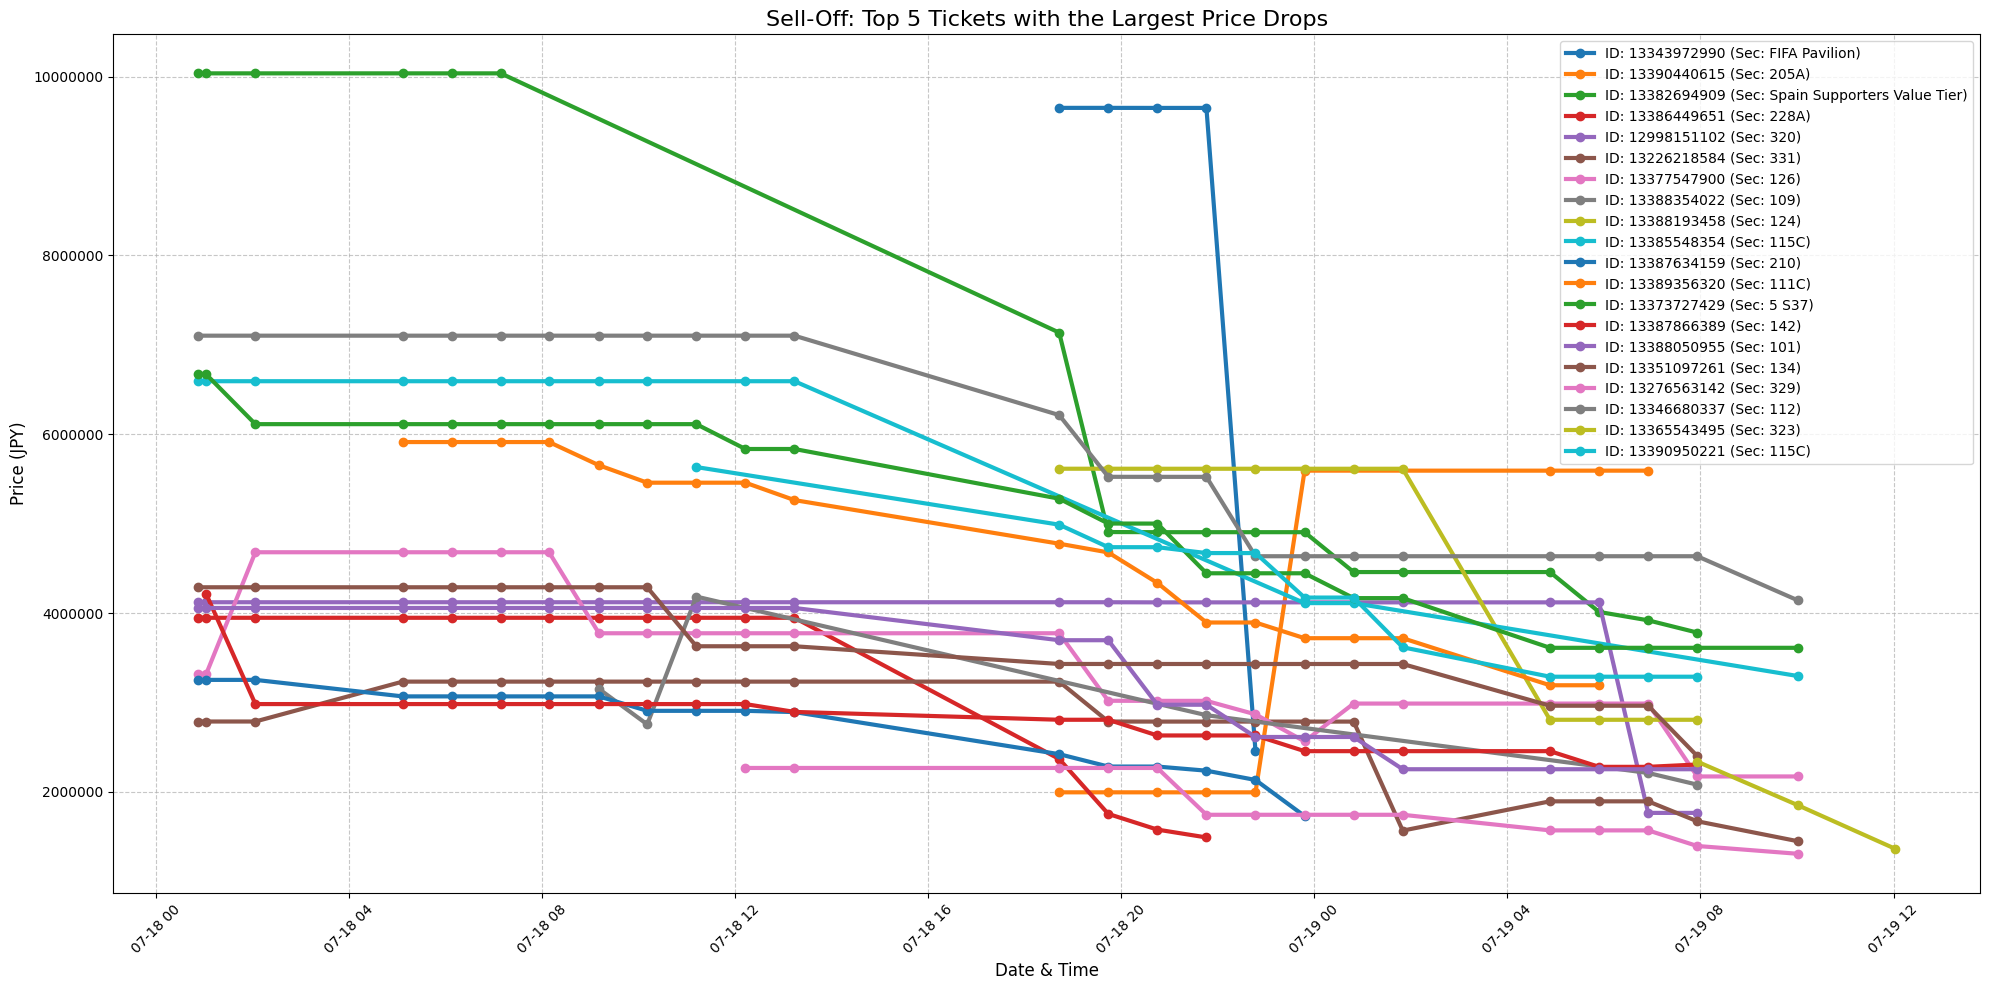

In [28]:
#tickets with large prices change
price_changes = all_tickets.groupby('id')['price_usd'].agg(['max', 'min']).reset_index()
price_changes['drop_amount'] = price_changes['max'] - price_changes['min']
price_changes['drop_percent'] = (price_changes['drop_amount'] / price_changes['max']).round(4) * 100

top_drops = price_changes.sort_values(by='drop_percent', ascending=False).head(20)
top_ids = top_drops['id'].tolist()

print('tickets with large price change')
display(top_drops)

plt.figure(figsize=(20, 10))

for ticket_id in top_ids:
    history = all_tickets[all_tickets['id'] == ticket_id].sort_values('scraped_time')
    section_info = str(history['section'].iloc[0])
    
    plt.plot(history['scraped_time'], history['rawPrice'], 
             marker='o', linewidth=3, label=f'ID: {ticket_id} (Sec: {section_info})')

plt.title('Sell-Off: Top 5 Tickets with the Largest Price Drops', fontsize=16)
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('Price (JPY)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
#bigUP id13390440615
display(
    all_tickets.loc[
        all_tickets["id"] == 13390440615,
        ["scraped_time", "price_usd", "price","rawPrice"]
    ].sort_values("scraped_time")
)

,scraped_time,price_usd,price,rawPrice
3891,2026-07-18 18:43:00,12322,"$12,322",1996228
2473,2026-07-18 19:44:00,12322,"$12,322",1996228
1579,2026-07-18 20:45:00,12321,"$12,321",1996106
3530,2026-07-18 21:46:00,12321,"$12,321",1996106
1770,2026-07-18 22:47:00,12321,"$12,321",1996106
388,2026-07-18 23:48:00,34527,"$34,527",5593394
1391,2026-07-19 04:53:00,34527,"$34,527",5593394
5006,2026-07-19 05:54:00,34527,"$34,527",5593394
3004,2026-07-19 06:55:00,34527,"$34,527",5593394


In [30]:
#bigDOWN id13343972990	
display(
    all_tickets.loc[
        all_tickets["id"] == 13343972990,
        ["scraped_time", "price_usd", "price","rawPrice"]
    ].sort_values("scraped_time")
)

,scraped_time,price_usd,price,rawPrice
3998,2026-07-18 18:43:00,59569,"$59,569",9650332
2579,2026-07-18 19:44:00,59569,"$59,569",9650332
1671,2026-07-18 20:45:00,59566,"$59,566",9649739
3616,2026-07-18 21:46:00,59566,"$59,566",9649739
1800,2026-07-18 22:47:00,15164,"$15,164",2456630


In [31]:
#price range
ticket_summary = (
    all_tickets
    .groupby("id")
    .agg(
        price_usd=("price_usd", "median"),
        availableTickets=("availableTickets", "max")
    )
    .reset_index()
)

bins = [
    0,
    10000,
    20000,
    30000,
    40000,
    50000,
    60000,
    70000,
    float("inf")
]

labels = [
    "Under $10k",
    "$10k–20k",
    "$20k–30k",
    "$30k–40k",
    "$40k–50k",
    "$50k–60k",
    "$60k–70k",
    "$70k+"
]

ticket_summary["price_band"] = pd.cut(
    ticket_summary["price_usd"],
    bins=bins,
    labels=labels,
    right=False
)

result = (
    ticket_summary
    .groupby("price_band", observed=False)
    .agg(
        ids=("id", "count"),
        availableTickets=("availableTickets", "sum")
    )
    .reset_index()
)

result

print(result)

   price_band  ids  availableTickets
0  Under $10k  271               592
1    $10k–20k  654              1615
2    $20k–30k   62               164
3    $30k–40k   27                87
4    $40k–50k    4                 9
5    $50k–60k    3                21
6    $60k–70k    1                 1
7       $70k+    0                 0


In [32]:
#tickets by section
section_summary = (
    all_tickets
    .groupby('section')
    .agg(
        unique_tickets=('id','nunique')
    )
    .reset_index()
)

section_summary.sort_values(
    by='unique_tickets',ascending=False)

,section,unique_tickets
19,124,58
20,126,50
36,204,42
50,227A,37
88,327,28
...,...,...
3,106,1
44,219,1
45,221A,1
10,113,1


In [33]:
#section_to_json
section_summary.to_json(
    "section_ticket_counts.json",
    orient="records",
    force_ascii=False,
    indent=2
)

In [34]:
#check ticket class
all_tickets[['section', 'ticketClass', 'ticketClassName']].sample(20)

,section,ticketClass,ticketClassName
1403,350,407,Upper
954,343,407,Upper
181,235,471,Middle
1772,225B,471,Middle
3820,327,407,Upper
2844,327,407,Upper
2469,124,594,Lower
3275,313,407,Upper
826,328,407,Upper
4097,311,407,Upper


In [35]:
#ids, tickets for each ticket class
ticket_class_summary = (
    all_tickets
    .groupby('ticketClassName')
    .agg(
        ids=('id', 'count'),
        tickets=('availableTickets', 'sum')
    )
    .reset_index()
)

ticket_class_summary

,ticketClassName,ids,tickets
0,Argentina Supporters,50,97
1,Category 1,26,28
2,Category 2,26,34
3,Category 3,25,63
4,Category 4,26,49
5,Hospitality,88,208
6,Loge,135,347
7,Lower,1902,4252
8,Middle,866,2028
9,Spain Supporters,91,301


In [36]:
#supporters no row,seat
supporters = all_tickets[
    all_tickets["ticketClassName"].isin(
        ["Argentina Supporters", "Spain Supporters"]
    )
]

supporters[['section', 'row','seat','price_usd','ticketClass', 'ticketClassName']]

,section,row,seat,price_usd,ticketClass,ticketClassName
61,Spain Supporters,NaN,_,12392,1666,Spain Supporters
86,Argentina Supporters,NaN,_,13769,36868,Argentina Supporters
119,Argentina Supporters Standard Tier,NaN,_,15646,36868,Argentina Supporters
157,Spain Supporters Standard Tier,NaN,_,19256,1666,Spain Supporters
196,Spain Supporters Value Tier,NaN,_,38549,1666,Spain Supporters
...,...,...,...,...,...,...
4910,Argentina Supporters,NaN,_,11012,36868,Argentina Supporters
4932,Spain Supporters,NaN,_,12388,1666,Spain Supporters
4952,Argentina Supporters Standard Tier,NaN,_,13479,36868,Argentina Supporters
4982,Spain Supporters Standard Tier,NaN,_,19255,1666,Spain Supporters


In [37]:
#UpperMiddleLower
upper_middle_lower = (
    all_tickets[
        all_tickets["ticketClassName"].isin(
            ["Upper", "Middle", "Lower"]
        )
    ]
    .groupby("ticketClassName")
    .agg(
        ids=("id", "nunique"),
        median_price=("price_usd", "median"),
        mean_price=("price_usd", "mean"),
        tickets=("availableTickets", "sum")
    )
    .reset_index()
)

upper_middle_lower

,ticketClassName,ids,median_price,mean_price,tickets
0,Lower,385,15829.0,18844.923764,4252
1,Middle,201,13905.5,16854.829099,2028
2,Upper,358,10522.0,11167.706195,4104


In [38]:
#last tickets
all_tickets["lastTicketInSectionMessage.message"].value_counts(dropna=False)

lastTicketInSectionMessage.message
NaN             3575
Last ticket      737
Last tickets     705
Name: count, dtype: int64

In [39]:
#sanky
df_target = subset.copy()

df_target = df_target.dropna(subset=['ticketClassName'])

mask = df_target['ticketClassName'].str.contains('lower|middle|upper', case=False, na=False)
df_filtered = df_target[mask].copy()

df_unique = df_filtered.groupby('id').agg({
    'ticketClassName': 'first',  
    'availableTickets': 'max', 
    'price_usd': 'max'      
}).reset_index()

def categorize_seat(name):
    name = str(name).lower()
    if 'lower' in name:
        return 'Lower'
    elif 'middle' in name:
        return 'Middle'
    elif 'upper' in name:
        return 'Upper'
    else:
        return 'Other'

def categorize_price(price):
    if pd.isna(price):
        return 'Unknown'
    if price < 10000:
        return 'Under $10k'
    elif 10000 <= price < 20000:
        return '$10k–20k'
    elif 20000 <= price < 40000:
        return '$20k–40k'
    elif 40000 <= price < 60000:
        return '$40k–60k'
    else:
        return '$60k+'

df_unique['Seat_Tier'] = df_unique['ticketClassName'].apply(categorize_seat)
df_unique['Price_Range'] = df_unique['price_usd'].apply(categorize_price)

df_flow = df_unique.groupby(['Seat_Tier', 'Price_Range'])['availableTickets'].sum().reset_index()
df_flow.columns = ['source', 'target', 'value']
df_flow = df_flow[df_flow['value'] > 0]

source_nodes = ['Upper', 'Middle', 'Lower']

target_nodes = [
    '$60k+',
    '$40k–60k',
    '$20k–40k',
    '$10k–20k',
    'Under $10k'
]

all_nodes = [n for n in source_nodes + target_nodes if n in df_flow['source'].values or n in df_flow['target'].values]
node_indices = {node: i for i, node in enumerate(all_nodes)}

source_indices = df_flow['source'].map(node_indices).tolist()
target_indices = df_flow['target'].map(node_indices).tolist()
values = df_flow['value'].tolist()

node_colors = []
node_x = []
node_y = []

for node in all_nodes:
    if node == 'Upper':
        node_colors.append('#1f77b4') 
        node_x.append(0.01)
        node_y.append(0.2)
    elif node == 'Middle':
        node_colors.append('#ff7f0e') 
        node_x.append(0.01)
        node_y.append(0.5)
    elif node == 'Lower':
        node_colors.append('#2ca02c') 
        node_x.append(0.01)
        node_y.append(0.8)
    else:
        node_x.append(0.99)
        if node == '$60k+':
            node_colors.append('#d62728') 
            node_y.append(0.1)
        elif node == '$40k–60k':
            node_colors.append('#d62728') 
            node_y.append(0.3)
        elif node == '$20k–40k':
            node_colors.append('#333333') 
            node_y.append(0.5)
        elif node == '$10k–20k':
            node_colors.append('#333333') 
            node_y.append(0.7)
        elif node == 'Under $10k':
            node_colors.append('#333333') 
            node_y.append(0.9)
        else:
            node_colors.append('#333333') 
            node_y.append(0.5)

link_colors = []
for _, row in df_flow.iterrows():
    if '$60k+' in row['target'] or '$40k' in row['target']:
         link_colors.append('rgba(214, 39, 40, 0.6)')
    else:
        if row['source'] == 'Lower':
            link_colors.append('rgba(44, 160, 44, 0.3)')
        elif row['source'] == 'Middle':
            link_colors.append('rgba(255, 127, 14, 0.3)')
        elif row['source'] == 'Upper':
            link_colors.append('rgba(31, 119, 180, 0.3)')
        else:
            link_colors.append('rgba(169, 169, 169, 0.3)')

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 25,
      thickness = 20,
      line = dict(color = 'black', width = 0.5),
      label = all_nodes,
      color = node_colors,
      x = node_x,
      y = node_y
    ),
    link = dict(
      source = source_indices,
      target = target_indices,
      value = values,
      color = link_colors
    )
)])

fig.update_layout(
    title_text='Ticket Tiers to Extreme Price Ranges (Highest Price on Top)',
    font_size=14,
    width=900,
    height=700,
    paper_bgcolor='#080808',
    plot_bgcolor='#080808',
    font=dict(color='#ffffff')
)

fig.write_html('sankey.html')
print('sankey.html saved')

sankey.html saved


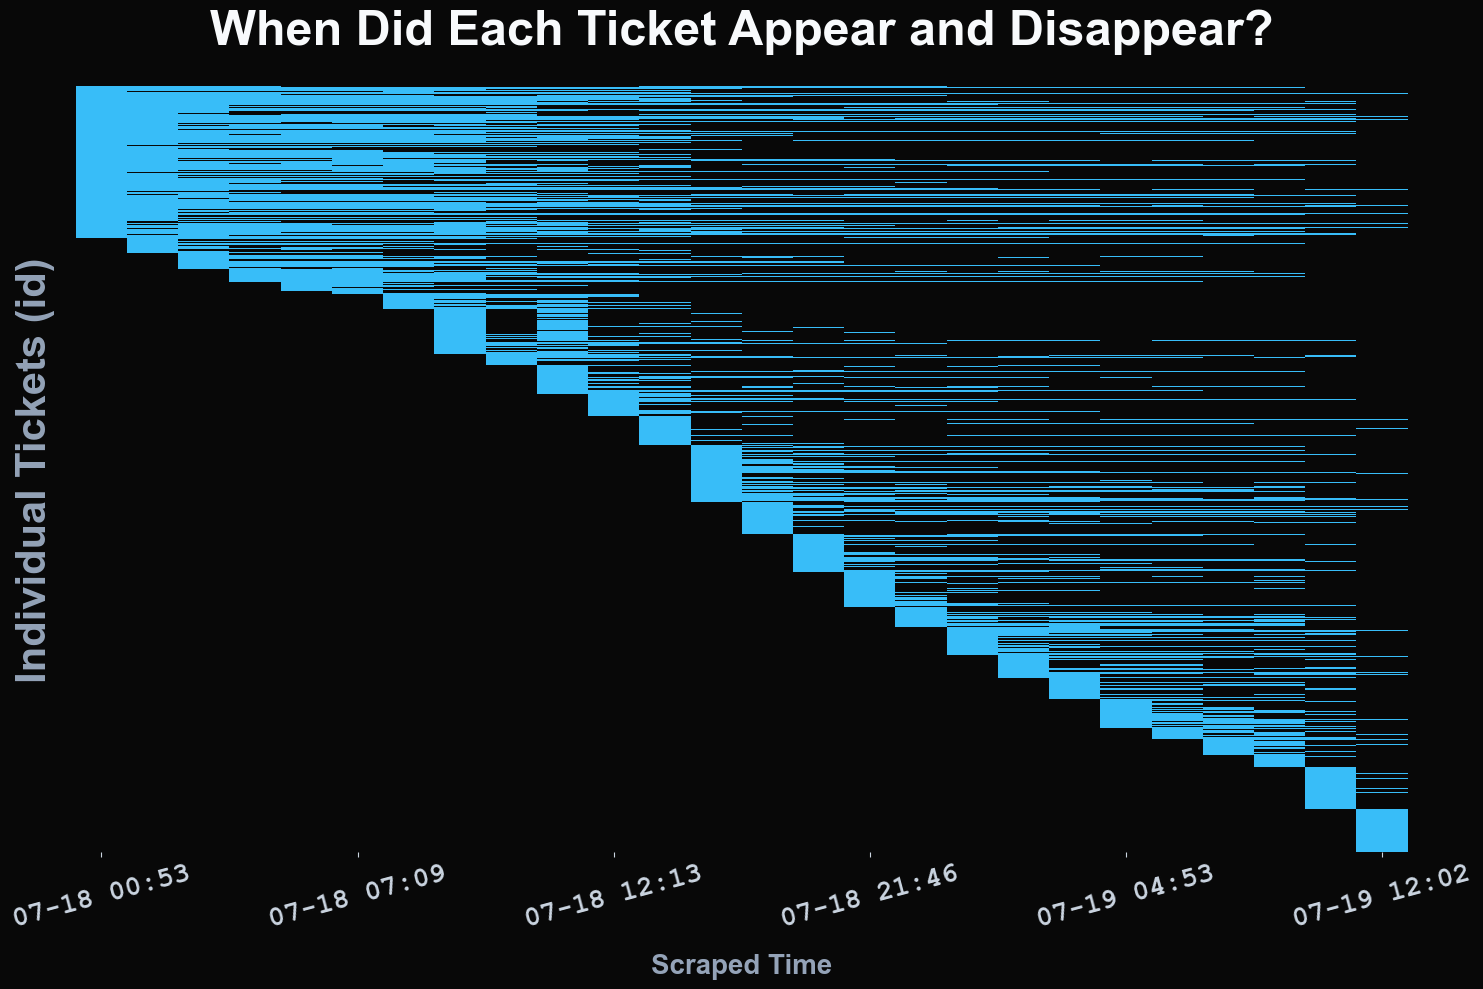

In [73]:
#appear and disappear
df_presence = all_tickets.copy()
df_presence['present'] = 1

matrix = df_presence.pivot_table(index='id', columns='scraped_time', values='present', fill_value=0)

first_seen = matrix.idxmax(axis=1)
matrix['first_seen'] = first_seen

matrix_waterfall = matrix.sort_values('first_seen').drop(columns=['first_seen'])

matrix_waterfall.columns = pd.to_datetime(matrix_waterfall.columns).strftime('%m-%d %H:%M')

plt.figure(figsize=(15, 10))
sns.heatmap(matrix_waterfall, cmap=["#080808", "#38bdf8"], cbar=False, 
            yticklabels=False, xticklabels=5)

plt.title('When Did Each Ticket Appear and Disappear?', 
          fontsize=35, color='#f8fafc', pad=30, fontweight='bold', fontfamily='Arial')

plt.xlabel('Scraped Time', fontsize=20, color='#94a3b8', fontfamily='Arial', labelpad=15,fontweight='bold')
plt.ylabel('Individual Tickets (id)', fontsize=30, color='#94a3b8', fontfamily='Arial', labelpad=15,fontweight='bold')

plt.xticks(fontsize=20, rotation=15, fontfamily='Courier New',fontweight='bold')

plt.gcf().set_facecolor('#080808')
plt.gca().set_facecolor('#080808')

plt.tick_params(colors='#cbd5e1') 

plt.tight_layout()
plt.savefig('matrix_waterfall.png', facecolor='#080808', dpi=300)
plt.show()